# Assignment 2 - CNN from Scratch on the MNIST Dataset

**Anjananand Iragavarapu** · Applied AIML 2 · a1987826

I designed a convolutional neural network which had two layers of convolution, two layers of max
pooling and two fully connected layers. I implemented convolution, pooling, forward propagation
and backpropagation using NumPy. I used torchvision only for downloading the data.

The network was trained with the parameters provided in the brief: batch size 32, learning rate
0.01, 5 epochs, and 80/20 split of the training set between training and validation sets.

## 1. Data Loading and Preprocessing

MNIST was loaded using torchvision per instructions provided. The original pixel values are
integers in the range between 0 and 255; I have normalized them to get pixel values in the range
of 0 and 1. Without doing so, the input data to the first convolution layer would be several
orders of magnitude greater than the weight of that layer and the loss would go haywire.

The input images are left in the form of 28x28 arrays. This is what CNNs are all about, the
filter needs to know where the adjacent pixels are located.

Out of 60,000 training samples, I have 48,000 for training and 12,000 for validation, in the
ratio of 80/20. The test dataset of 10,000 images remains untouched until the very end, as I use
the validation data only to choose epoch weights.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from torchvision import datasets

SEED = 42
EPOCHS, BATCH_SIZE, LEARNING_RATE = 5, 32, 0.01    

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# download MNIST and pull out the raw arrays
train_set = datasets.MNIST(root="./data", train=True, download=True)
test_set = datasets.MNIST(root="./data", train=False, download=True)

X_all = train_set.data.numpy()
y_all = train_set.targets.numpy()
X_test = test_set.data.numpy()
y_test = test_set.targets.numpy()

print("raw train:", X_all.shape, "| raw test:", X_test.shape, "| pixel range:", X_all.min(), X_all.max())

raw train: (60000, 28, 28) | raw test: (10000, 28, 28) | pixel range: 0 255


In [3]:
# turn integer labels into one-hot rows
def one_hot(y, n=10):
    return np.eye(n, dtype=np.float32)[y]


# scale pixels to 0-1 
def prepare(X):
    return (X.astype(np.float32) / 255.0).reshape(-1, 1, 28, 28)


X_all_p, X_test = prepare(X_all), prepare(X_test)

# 80/20 split of the training set, validation used only for choosing the best epoch
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X_all_p))
n_val = int(0.2 * len(X_all_p))

X_val, y_val = X_all_p[perm[:n_val]], y_all[perm[:n_val]]
X_train, y_train = X_all_p[perm[n_val:]], y_all[perm[n_val:]]
Y_train = one_hot(y_train)

print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)
print("pixel range after scaling:", X_train.min(), X_train.max())
print("train class counts:", np.bincount(y_train))

train: (48000, 1, 28, 28) | val: (12000, 1, 28, 28) | test: (10000, 1, 28, 28)
pixel range after scaling: 0.0 1.0
train class counts: [4712 5373 4769 4864 4674 4358 4739 5043 4699 4769]


## 2. Building Blocks

A convolution is a filter moving across the image pixel by pixel and computing a dot product
between the filter and the corresponding patch. While such computation using four nested for-loops
will work, it would be very inefficient for training on 48,000 images, so I used the standard
im2col trick.

It involves flattening every 3 by 3 image patch into one row of a matrix. Once the patches are
converted into rows, the entire convolution becomes one matrix multiplication, which NumPy performs
very fast. In the backward direction, the gradients from those rows need to be scattered back onto
the image grid, which is done by the col2im operation. Because overlapping patches share pixels,
the gradients have to be summed rather than overwritten.

Here are my layer sizes. The input is 1 x 28 x 28. My first convolutional layer with 6 filters,
each of size 3 x 3 with no padding, gives an output of 6 x 26 x 26. Max pooling halves this to
6 x 13 x 13. The second convolution with 16 filters of 3 x 3 gives 16 x 11 x 11, and max pooling
then gives 16 x 5 x 5, since 11 is odd and the last row and column are dropped. Flattening gives
400 features, which feed into 128 units and then 10 outputs.

In [4]:

def im2col(X, kh, kw):
    N, C, H, W = X.shape
    win = sliding_window_view(X, (kh, kw), axis=(2, 3))         
    OH, OW = H - kh + 1, W - kw + 1
    return win.transpose(0, 2, 3, 1, 4, 5).reshape(N, OH * OW, C * kh * kw), OH, OW


# scatter the column gradients back onto the image grid, adding where patches overlap
def col2im(dcols, X_shape, kh, kw, OH, OW):
    N, C, H, W = X_shape
    dX = np.zeros(X_shape, dtype=dcols.dtype)
    d = dcols.reshape(N, OH, OW, C, kh, kw)
    for i in range(kh):
        for j in range(kw):
            dX[:, :, i:i + OH, j:j + OW] += d[:, :, :, :, i, j].transpose(0, 3, 1, 2)
    return dX

In [5]:
# convolutional layer with He initialised filters and zero biases
class Conv:
    def __init__(self, n_filters, in_ch, k, rng):
        std = np.sqrt(2.0 / (in_ch * k * k))       # He init, fan-in is one filter's worth of pixels
        self.W = (rng.standard_normal((n_filters, in_ch, k, k)) * std).astype(np.float32)
        self.b = np.zeros(n_filters, dtype=np.float32)
        self.k = k

    def forward(self, X):
        self.X_shape = X.shape
        cols, OH, OW = im2col(X, self.k, self.k)
        self.cols, self.OH, self.OW = cols, OH, OW
        F = self.W.shape[0]
        out = cols @ self.W.reshape(F, -1).T + self.b          
        return out.transpose(0, 2, 1).reshape(X.shape[0], F, OH, OW)

    def backward(self, dout):
        N, F = dout.shape[0], dout.shape[1]
        d = dout.reshape(N, F, -1).transpose(0, 2, 1)          
        self.dW = np.einsum('npf,npk->fk', d, self.cols).reshape(self.W.shape)
        self.db = d.sum(axis=(0, 1))
        dcols = d @ self.W.reshape(F, -1)
        return col2im(dcols, self.X_shape, self.k, self.k, self.OH, self.OW)


# max pooling
class MaxPool:
    def __init__(self, size=2):
        self.s = size

    def forward(self, X):
        s = self.s
        N, C, H, W = X.shape
        H2, W2 = H // s * s, W // s * s             # crop odd edges, 11 becomes 10
        self.X_shape, self.H2, self.W2 = X.shape, H2, W2
        Xc = X[:, :, :H2, :W2].reshape(N, C, H2 // s, s, W2 // s, s)
        Xc = Xc.transpose(0, 1, 2, 4, 3, 5).reshape(N, C, H2 // s, W2 // s, s * s)
        self.idx = Xc.argmax(-1)                    # winner index inside each window
        return np.take_along_axis(Xc, self.idx[..., None], -1).squeeze(-1)

    def backward(self, dout):
        s = self.s
        N, C, H, W = self.X_shape
        OH, OW = self.H2 // s, self.W2 // s
        flat = np.zeros((N, C, OH, OW, s * s), dtype=dout.dtype)
        np.put_along_axis(flat, self.idx[..., None], dout[..., None], -1)
        g = flat.reshape(N, C, OH, OW, s, s).transpose(0, 1, 2, 4, 3, 5)
        dX = np.zeros(self.X_shape, dtype=dout.dtype)
        dX[:, :, :self.H2, :self.W2] = g.reshape(N, C, self.H2, self.W2)
        return dX


# ordinary fully connected layer
class Dense:
    def __init__(self, n_in, n_out, rng):
        self.W = (rng.standard_normal((n_in, n_out)) * np.sqrt(2.0 / n_in)).astype(np.float32)
        self.b = np.zeros(n_out, dtype=np.float32)

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dout):
        self.dW = self.X.T @ dout
        self.db = dout.sum(0)
        return dout @ self.W.T

In [6]:
# ReLU: keep positives, zero out negatives
def relu(z):
    return np.maximum(0.0, z)


# turn each row of scores into probabilities that sum to one
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))        
    return e / e.sum(axis=1, keepdims=True)


# average cross-entropy across the batch
def cross_entropy(P, Y, eps=1e-12):
    return -np.mean(np.sum(Y * np.log(np.clip(P, eps, 1.0)), axis=1))


# fraction of samples predicted correctly
def accuracy(y_pred, y_true):
    return float(np.mean(y_pred == y_true))

## 3. The CNN Class

I wired the blocks together in one class. The backward pass goes through the layers in reverse
order, and at each ReLU I multiply by the mask of units that were active on the forward pass.

Softmax and cross-entropy simplify when combined: the resulting derivative is simply the
difference between predictions and labels divided by the batch size, so I never had to compute
the Jacobian of the softmax function.

I also added an optional dropout on the 128 unit layer. It is turned off by default and only
enabled for my experiment in section 9. I used inverted dropout, which scales up the surviving
units during training so no rescaling is needed at test time.

In [7]:
# two conv layers, two pooling layers, two dense layers
class CNN:
    def __init__(self, seed=SEED, p_drop=0.0):
        rng = np.random.default_rng(seed)
        self.c1 = Conv(6, 1, 3, rng)               
        self.p1 = MaxPool(2)                      
        self.c2 = Conv(16, 6, 3, rng)             
        self.p2 = MaxPool(2)                       
        self.f1 = Dense(16 * 5 * 5, 128, rng)      
        self.f2 = Dense(128, 10, rng)              
        self.p_drop = p_drop
        self.rng = rng

    def forward(self, X, training=True):
        z1 = self.c1.forward(X); self.m1 = z1 > 0            
        p1 = self.p1.forward(relu(z1))
        z2 = self.c2.forward(p1); self.m2 = z2 > 0
        p2 = self.p2.forward(relu(z2))

        self.flat_shape = p2.shape
        z3 = self.f1.forward(p2.reshape(p2.shape[0], -1))
        a3 = relu(z3); self.m3 = z3 > 0

        if self.p_drop > 0 and training:
            # inverted dropout, scale up 
            self.drop = (self.rng.random(a3.shape) > self.p_drop) / (1 - self.p_drop)
            a3 = a3 * self.drop
        else:
            self.drop = None

        return softmax(self.f2.forward(a3))

    def backward(self, P, Y):
        d = (P - Y) / P.shape[0]                  
        d = self.f2.backward(d)
        if self.drop is not None:
            d = d * self.drop
        d = self.f1.backward(d * self.m3)
        d = self.p2.backward(d.reshape(self.flat_shape))
        d = self.c2.backward(d * self.m2)
        d = self.p1.backward(d)
        self.c1.backward(d * self.m1)

    def layers(self):
        return [self.c1, self.c2, self.f1, self.f2]

    # nudge every parameter a small step against its gradient
    def step(self, lr):
        for L in self.layers():
            L.W -= lr * L.dW
            L.b -= lr * L.db

    def predict(self, X):
        return np.argmax(self.forward(X, training=False), axis=1)


print("parameters:", sum(L.W.size + L.b.size for L in CNN().layers()))

parameters: 53558


## 4. Checking the Gradients

Getting backpropagation through a convolution wrong in a way that still runs is surprisingly
easy, especially in `col2im`, which must sum overlapping contributions rather than overwrite them.
Overwriting still makes the loss fall, just along the wrong path. So I checked every layer
numerically before training anything.

One issue here is worth writing about. My first numerical check gave a relative error of 1.0 on
the convolutional biases, which looked like a bug. It was not. MNIST images are mostly black
border, so a 3 by 3 filter placed on an all-zero region gives exactly zero. With the biases
initialised to zero, the pre-activation lands exactly on zero, where ReLU has no derivative and
my implementation returns 0. Out of 129,792 first layer pre-activations, 80,370 sit exactly at
zero. So nudging the bias by a tiny amount pushes those units positive, and the numerical estimate
sees a change that my analytical gradient does not.

The check is therefore run on random input with the biases nudged slightly off zero, so that no
unit sits at the kink. This tests the same code without asking it to be differentiable at a point
where it is not.

Another issue followed straight after. The check still failed, this time because the network runs
in float32 to keep training fast. A central difference subtracts two loss values that differ by
only around 1e-7, and float32 carries only about seven decimal digits, so the result is noise
instead of the gradient. Casting the parameters to float64 for the duration of the check fixes it.
Training itself stays in float32, since only the finite difference needs the extra precision.

In [8]:
# compare analytical gradients against central-difference numerical ones
def gradient_check(eps=1e-6, n_per_param=8, seed=1):
    r = np.random.default_rng(seed)
    X = (r.standard_normal((8, 1, 28, 28)) * 0.5 + 0.5)         
    Y = one_hot(r.integers(0, 10, 8)).astype(np.float64)

    m = CNN(seed=0)
    for L in m.layers():
        L.W = L.W.astype(np.float64)                 
        L.b = L.b.astype(np.float64)
    for L in [m.c1, m.c2]:
        L.b += 0.01                                  # nudge biases off the ReLU
    m.backward(m.forward(X), Y)

    worst = 0.0
    for L in m.layers():
        for pname in ["W", "b"]:
            P, D = getattr(L, pname), getattr(L, "d" + pname)
            for f in r.choice(P.size, size=min(n_per_param, P.size), replace=False):
                i = np.unravel_index(f, P.shape)
                o = P[i]
                P[i] = o + eps; lp = cross_entropy(m.forward(X), Y)
                P[i] = o - eps; lm = cross_entropy(m.forward(X), Y)
                P[i] = o
                num, an = (lp - lm) / (2 * eps), D[i]
                if max(abs(num), abs(an)) > 1e-7:    # relative error is meaningless near zero
                    worst = max(worst, abs(num - an) / (abs(num) + abs(an)))
    return worst


# count units sitting exactly at zero
probe = CNN(seed=0)
z1 = probe.c1.forward(X_train[:32])
at_kink = int((np.abs(z1) < 1e-6).sum())
print(f"first-layer pre-activations exactly at the ReLU kink: {at_kink} of {z1.size}")

worst = gradient_check()
print(f"Worst relative error: {worst:.2e}")
print("PASS - my backward pass agrees with the numerical estimate" if worst < 1e-5 else "FAIL")

first-layer pre-activations exactly at the ReLU kink: 80370 of 129792
Worst relative error: 4.21e-08
PASS - my backward pass agrees with the numerical estimate


## 5. Training Loop and Model Selection

I trained using mini-batch SGD with the prescribed settings and shuffled the data every epoch.
48,000 images in batches of 32 gives 1,500 batches per epoch, so 7,500 weight updates over the
five epochs.

Model selection is the part worth explaining. After every epoch I evaluate the network on the
validation set and keep a copy of the weights whenever validation accuracy improves. At the end of
training I restore the best version and only then use the test set. This means the epoch I submit
is chosen using data the model never trained on, and the test accuracy stays an honest measure.

In [9]:
# score a model in batches without updating anything
def evaluate(model, X, y, bs=500):
    loss, correct = 0.0, 0
    Y = one_hot(y)
    for s in range(0, len(X), bs):
        P = model.forward(X[s:s + bs], training=False)
        loss += cross_entropy(P, Y[s:s + bs]) * len(P)
        correct += (np.argmax(P, 1) == y[s:s + bs]).sum()
    return loss / len(X), correct / len(X)


# train with mini-batch SGD, keeping the weights from the best validation epoch
def train(model, Xt, Yt, yt, Xv, yv, epochs=EPOCHS, bs=BATCH_SIZE,
          lr=LEARNING_RATE, seed=SEED, verbose=True):
    r = np.random.default_rng(seed)
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best = {"val_acc": -1.0}

    for ep in range(epochs):
        order = r.permutation(len(Xt))             
        run_loss, run_correct = 0.0, 0

        for s in range(0, len(Xt), bs):
            b = order[s:s + bs]
            P = model.forward(Xt[b])
            run_loss += cross_entropy(P, Yt[b]) * len(b)
            run_correct += (np.argmax(P, 1) == yt[b]).sum()
            model.backward(P, Yt[b])
            model.step(lr)

        tl, ta = run_loss / len(Xt), run_correct / len(Xt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["train_acc"].append(ta)
        hist["val_loss"].append(vl); hist["val_acc"].append(va)

        if va > best["val_acc"]:                   # snapshot the best epoch so far
            best = {"val_acc": va, "epoch": ep + 1,
                    "weights": [(L.W.copy(), L.b.copy()) for L in model.layers()]}

        if verbose:
            print(f"Epoch {ep + 1}/{epochs} - Loss: {tl:.4f}, Accuracy: {ta:.4f}"
                  f" | val_loss: {vl:.4f}, val_acc: {va:.4f}")

    for L, (W, b) in zip(model.layers(), best["weights"]):   # restore the best epoch
        L.W[...], L.b[...] = W, b
    return hist, best["epoch"]

## 6. Training the Model

In [10]:
model = CNN(seed=SEED)
history, best_epoch = train(model, X_train, Y_train, y_train, X_val, y_val)

print(f"\nBatches per epoch: {int(np.ceil(len(X_train) / BATCH_SIZE))}")
print(f"Total updates    : {int(np.ceil(len(X_train) / BATCH_SIZE)) * EPOCHS}")
print(f"Best epoch by validation accuracy: {best_epoch}")

Epoch 1/5 - Loss: 0.4253, Accuracy: 0.8735 | val_loss: 0.1843, val_acc: 0.9443
Epoch 2/5 - Loss: 0.1544, Accuracy: 0.9539 | val_loss: 0.1326, val_acc: 0.9594
Epoch 3/5 - Loss: 0.1156, Accuracy: 0.9647 | val_loss: 0.1102, val_acc: 0.9682
Epoch 4/5 - Loss: 0.0960, Accuracy: 0.9703 | val_loss: 0.0901, val_acc: 0.9732
Epoch 5/5 - Loss: 0.0828, Accuracy: 0.9746 | val_loss: 0.0838, val_acc: 0.9751

Batches per epoch: 1500
Total updates    : 7500
Best epoch by validation accuracy: 5


## 7. Evaluation

In [11]:
y_pred = model.predict(X_test)
test_acc = accuracy(y_pred, y_test)

print(f"Test Accuracy: {test_acc:.4f}  ({int(round(test_acc * len(y_test)))}/{len(y_test)})")
print(f"Final training accuracy  : {history['train_acc'][-1]:.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")

Test Accuracy: 0.9802  (9802/10000)
Final training accuracy  : 0.9746
Final validation accuracy: 0.9751


In [12]:
# count predictions against truth
def confusion_matrix(y_true, y_pred, n=10):
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


cm = confusion_matrix(y_test, y_pred)

print("Class  Precision   Recall     F1   Support")
for i in range(10):
    tp = cm[i, i]
    prec = tp / cm[:, i].sum() if cm[:, i].sum() else 0.0    # of those predicted, how many right
    rec = tp / cm[i, :].sum() if cm[i, :].sum() else 0.0     # of those actual, how many found
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    print(f"{i:^5}{prec:>11.3f}{rec:>9.3f}{f1:>7.3f}{cm[i].sum():>10}")


off = cm - np.diag(np.diag(cm))
pairs = np.dstack(np.unravel_index(np.argsort(off, axis=None)[::-1][:3], off.shape))[0]
print("\nmost confused pairs (true -> predicted):")
for t, p in pairs:
    print(f"  {t} mistaken for {p}: {off[t, p]} times")

Class  Precision   Recall     F1   Support
  0        0.984    0.991  0.987       980
  1        0.989    0.993  0.991      1135
  2        0.986    0.968  0.977      1032
  3        0.986    0.970  0.978      1010
  4        0.975    0.986  0.980       982
  5        0.978    0.983  0.980       892
  6        0.994    0.979  0.986       958
  7        0.958    0.986  0.972      1028
  8        0.967    0.979  0.973       974
  9        0.986    0.965  0.975      1009

most confused pairs (true -> predicted):
  2 mistaken for 7: 18 times
  3 mistaken for 5: 11 times
  9 mistaken for 7: 9 times


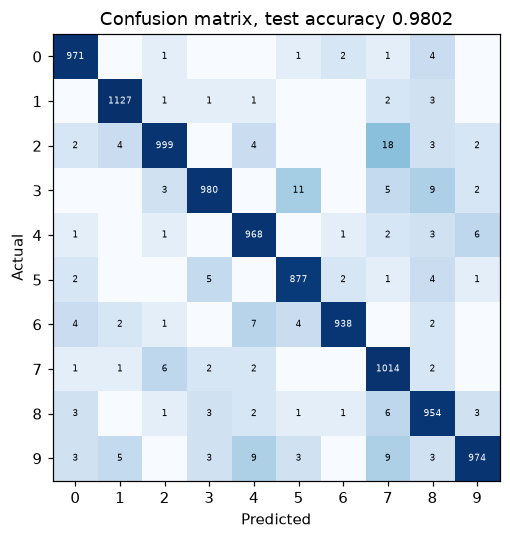

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.log1p(cm), cmap="Blues")          
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix, test accuracy {test_acc:.4f}")
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=6,
                    color="white" if i == j else "black")
ax.grid(False)
fig.tight_layout()
plt.savefig("fig_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

198 misclassified of 10000
mean confidence when wrong  : 0.691
mean confidence when correct: 0.980


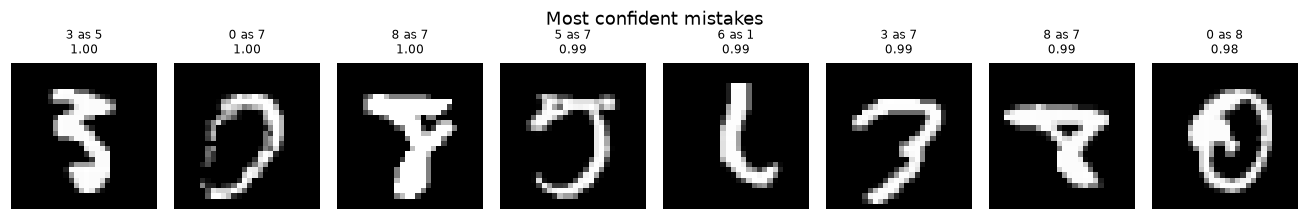

In [14]:
# look at what it got wrong and how sure it was when it did
probs = model.forward(X_test, training=False)
wrong = np.where(y_pred != y_test)[0]
conf = probs[wrong].max(1)

print(f"{len(wrong)} misclassified of {len(y_test)}")
print(f"mean confidence when wrong  : {conf.mean():.3f}")
print(f"mean confidence when correct: {probs[y_pred == y_test].max(1).mean():.3f}")

worst = wrong[np.argsort(conf)[::-1][:8]]            # the mistakes it was most sure about
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, i in zip(axes, worst):
    ax.imshow(X_test[i, 0], cmap="gray")
    ax.set_title(f"{y_test[i]} as {y_pred[i]}\n{probs[i].max():.2f}", fontsize=8)
    ax.axis("off")
fig.suptitle("Most confident mistakes")
fig.tight_layout()
plt.savefig("fig_mistakes.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Learning Curves

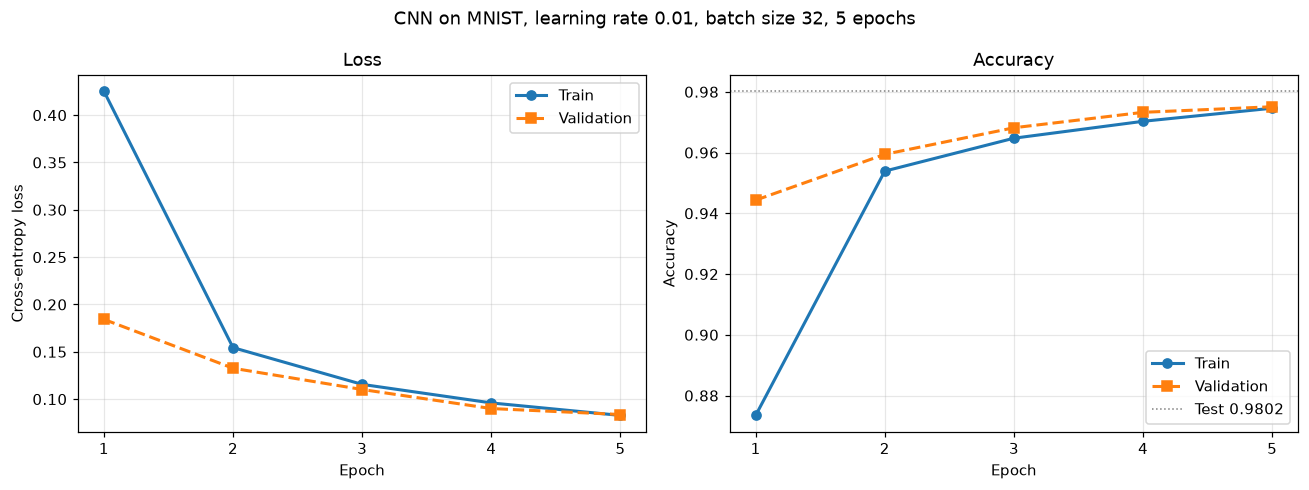

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ep_axis = np.arange(1, EPOCHS + 1)

axes[0].plot(ep_axis, history["train_loss"], marker="o", label="Train", lw=2)
axes[0].plot(ep_axis, history["val_loss"], marker="s", label="Validation", lw=2, ls="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Loss"); axes[0].set_xticks(ep_axis); axes[0].legend()

axes[1].plot(ep_axis, history["train_acc"], marker="o", label="Train", lw=2)
axes[1].plot(ep_axis, history["val_acc"], marker="s", label="Validation", lw=2, ls="--")
axes[1].axhline(test_acc, color="grey", ls=":", lw=1, label=f"Test {test_acc:.4f}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].set_xticks(ep_axis); axes[1].legend()

fig.suptitle("CNN on MNIST, learning rate 0.01, batch size 32, 5 epochs")
fig.tight_layout()
plt.savefig("fig_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Three things stand out in these curves.

The validation curve stays close to the training curve for the entire run rather than drifting
away from it, so there is no overfitting at this budget. Validation accuracy is slightly higher
than training accuracy, which seems odd at first but is logical: the training number is an average
over the whole epoch while the weights were still improving, whereas validation is measured once
at the end of the epoch with the finished weights.

Both curves are still improving at epoch 5, which means the model has not converged yet. It simply
ran out of the epochs the brief allows.

The test accuracy is higher than the validation accuracy. With 10,000 test images and 12,000
validation images, the sampling noise on each is only a few tenths of a percent, so this is a
small but real difference rather than a fluke.

### Testing the underfitting claim

The curves say the model has not converged at epoch 5. If that is true, the same model trained for
longer should keep improving. I trained it again for 10 epochs with every other setting unchanged,
using the same best-validation-epoch selection.

In [16]:
# same model and settings, only the epoch budget doubled
model_long = CNN(seed=SEED)
hist_long, ep_long = train(model_long, X_train, Y_train, y_train, X_val, y_val, epochs=10)
acc_long = accuracy(model_long.predict(X_test), y_test)

print(f"\n{'Epochs':<8}{'Best epoch':>12}{'Train acc':>11}{'Val acc':>10}{'Test acc':>10}")
print(f"{5:<8}{best_epoch:>12}{history['train_acc'][-1]:>11.4f}{max(history['val_acc']):>10.4f}{test_acc:>10.4f}")
print(f"{10:<8}{ep_long:>12}{hist_long['train_acc'][-1]:>11.4f}{max(hist_long['val_acc']):>10.4f}{acc_long:>10.4f}")

Epoch 1/10 - Loss: 0.4253, Accuracy: 0.8735 | val_loss: 0.1843, val_acc: 0.9443
Epoch 2/10 - Loss: 0.1544, Accuracy: 0.9539 | val_loss: 0.1326, val_acc: 0.9594
Epoch 3/10 - Loss: 0.1156, Accuracy: 0.9647 | val_loss: 0.1102, val_acc: 0.9682
Epoch 4/10 - Loss: 0.0960, Accuracy: 0.9703 | val_loss: 0.0901, val_acc: 0.9732
Epoch 5/10 - Loss: 0.0828, Accuracy: 0.9746 | val_loss: 0.0838, val_acc: 0.9751
Epoch 6/10 - Loss: 0.0739, Accuracy: 0.9772 | val_loss: 0.0813, val_acc: 0.9742
Epoch 7/10 - Loss: 0.0661, Accuracy: 0.9797 | val_loss: 0.0792, val_acc: 0.9748
Epoch 8/10 - Loss: 0.0607, Accuracy: 0.9816 | val_loss: 0.0699, val_acc: 0.9788
Epoch 9/10 - Loss: 0.0557, Accuracy: 0.9829 | val_loss: 0.0709, val_acc: 0.9774
Epoch 10/10 - Loss: 0.0521, Accuracy: 0.9835 | val_loss: 0.0692, val_acc: 0.9781

Epochs    Best epoch  Train acc   Val acc  Test acc
5                  5     0.9746    0.9751    0.9802
10                 8     0.9835    0.9788    0.9833


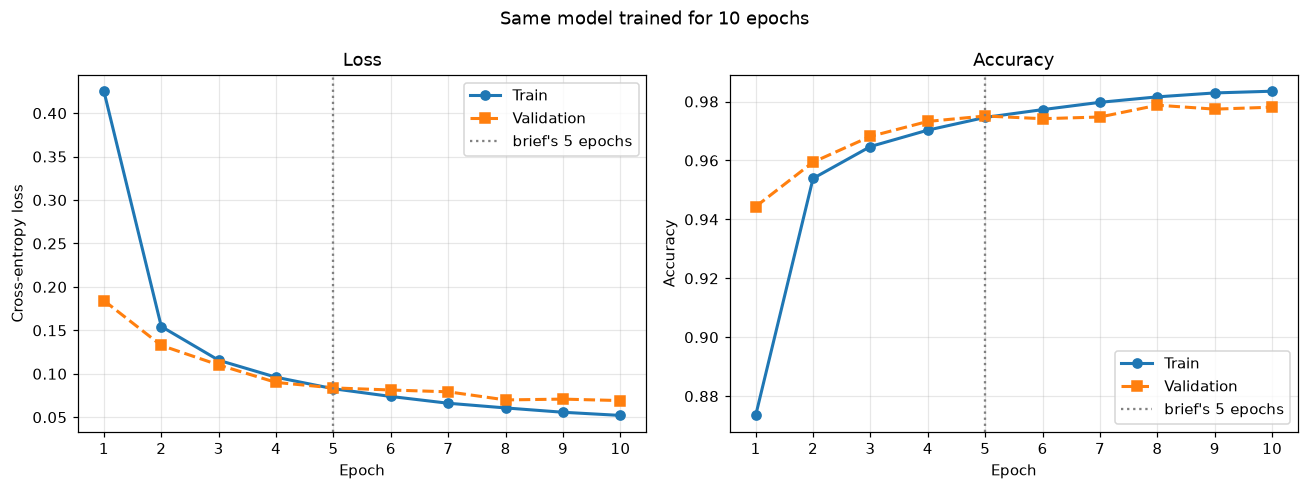

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ep10 = np.arange(1, 11)

axes[0].plot(ep10, hist_long["train_loss"], marker="o", lw=2, label="Train")
axes[0].plot(ep10, hist_long["val_loss"], marker="s", lw=2, ls="--", label="Validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss"); axes[0].set_title("Loss")

axes[1].plot(ep10, hist_long["train_acc"], marker="o", lw=2, label="Train")
axes[1].plot(ep10, hist_long["val_acc"], marker="s", lw=2, ls="--", label="Validation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")

for ax in axes:
    ax.axvline(5, color="grey", ls=":", lw=1.5, label="brief's 5 epochs")   # where the brief stops
    ax.set_xticks(ep10); ax.legend()

fig.suptitle("Same model trained for 10 epochs")
fig.tight_layout()
plt.savefig("fig_longer.png", dpi=150, bbox_inches="tight")
plt.show()

Training for 10 epochs raised test accuracy from 0.9802 to 0.9833, and the best validation epoch
was 8. So the model was underfitting at the brief's budget of 5 epochs: the limit was training
time, not the architecture.

After epoch 8, validation accuracy stops improving while training accuracy keeps rising. That is
roughly where overfitting would begin, and where a regularizer like dropout would start to help.

## 9. Regularization Experiment

Since question 3 asks for a regularization method and the brief asks for experiments that show it
works, I tested dropout rather than just describing it.

In my first trial, I applied dropout with probability 0.25 to the 128 unit layer, leaving all
other settings unchanged. In the second trial, I deliberately created overfitting by reducing the
training set to 5,000 images and training for 20 epochs, then compared dropout 0.5 against no
dropout. I did this because the baseline does not overfit, and a regularizer cannot show its
effect on a problem that is not there.

In [18]:
# same budget as the baseline, just with dropout switched on
model_drop = CNN(seed=SEED, p_drop=0.25)
hist_drop, ep_drop = train(model_drop, X_train, Y_train, y_train, X_val, y_val, verbose=False)
acc_drop = accuracy(model_drop.predict(X_test), y_test)

print(f"{'Setting':<22}{'Train acc':>11}{'Val acc':>10}{'Test acc':>10}")
print(f"{'no dropout':<22}{history['train_acc'][-1]:>11.4f}{history['val_acc'][-1]:>10.4f}{test_acc:>10.4f}")
print(f"{'dropout 0.25':<22}{hist_drop['train_acc'][-1]:>11.4f}{hist_drop['val_acc'][-1]:>10.4f}{acc_drop:>10.4f}")

Setting                 Train acc   Val acc  Test acc
no dropout                 0.9746    0.9751    0.9802
dropout 0.25               0.9642    0.9753    0.9784


In [19]:
# shrink the training set and train longer so overfitting actually appears
sub = np.random.default_rng(0).permutation(len(X_train))[:5000]
Xs, Ys, ys = X_train[sub], Y_train[sub], y_train[sub]

small = {}
for p in [0.0, 0.5]:
    m = CNN(seed=SEED, p_drop=p)
    h, be = train(m, Xs, Ys, ys, X_val, y_val, epochs=20, verbose=False)
    small[p] = (h, accuracy(m.predict(X_test), y_test), be)

print("5,000 training images, 20 epochs\n")
print(f"{'Setting':<16}{'Train acc':>11}{'Val acc':>10}{'Gap':>9}{'Test acc':>10}{'Best ep':>9}")
for p, (h, te, be) in small.items():
    gap = h["train_acc"][-1] - h["val_acc"][-1]
    label = "no dropout" if p == 0 else f"dropout {p}"
    print(f"{label:<16}{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>10.4f}{gap:>+9.4f}{te:>10.4f}{be:>9}")

5,000 training images, 20 epochs

Setting           Train acc   Val acc      Gap  Test acc  Best ep
no dropout           0.9804    0.9495  +0.0309    0.9573       15
dropout 0.5          0.9394    0.9537  -0.0143    0.9595       20


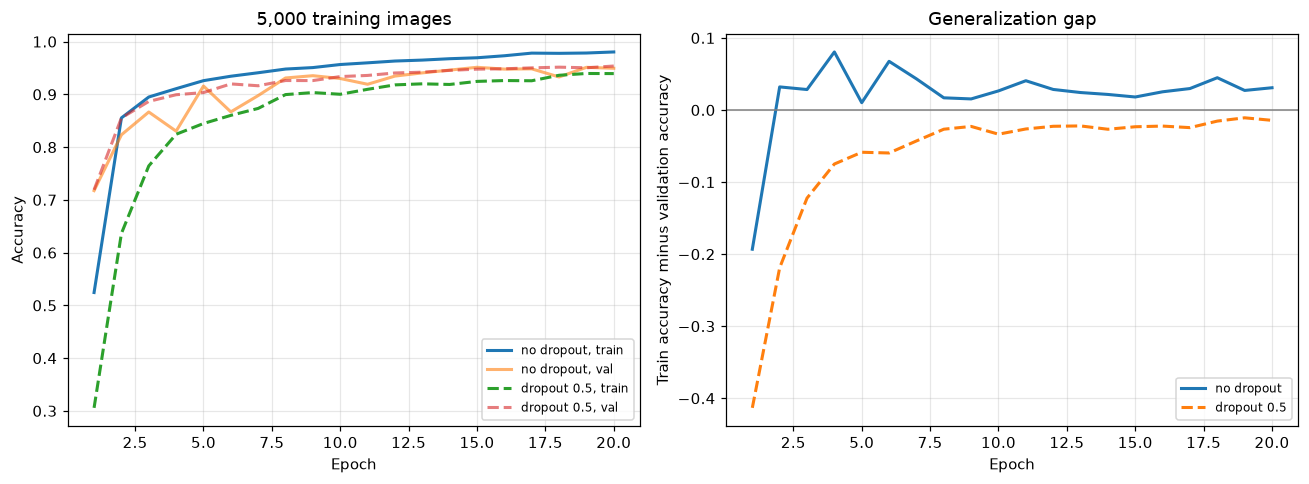

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax_ep = np.arange(1, 21)

for p, style in [(0.0, "-"), (0.5, "--")]:
    h, te, _ = small[p]
    label = "no dropout" if p == 0 else "dropout 0.5"
    axes[0].plot(ax_ep, h["train_acc"], style, lw=2, label=f"{label}, train")
    axes[0].plot(ax_ep, h["val_acc"], style, lw=2, alpha=0.6, label=f"{label}, val")
    axes[1].plot(ax_ep, np.array(h["train_acc"]) - np.array(h["val_acc"]), style, lw=2, label=label)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("5,000 training images"); axes[0].legend(fontsize=8)
axes[1].axhline(0, color="grey", lw=1)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Train accuracy minus validation accuracy")
axes[1].set_title("Generalization gap"); axes[1].legend(fontsize=8)

fig.tight_layout()
plt.savefig("fig_dropout.png", dpi=150, bbox_inches="tight")
plt.show()



Dropout slightly decreases performance on the full training set over five epochs. This is the
right outcome rather than a failure. There is nothing to regularize yet, since the model is not
overfitting, so dropout only removes capacity from a model that has not finished learning.

With 5,000 images and 20 epochs, the situation changes. Without dropout, training accuracy
overtakes validation accuracy and the gap keeps widening, which is textbook overfitting. When I
add dropout, the gap closes to roughly zero and test accuracy improves.

So dropout is worth using, but only once the model starts memorizing. Applying it by reflex to an
underfitting model costs accuracy.

## 10. AI Use Statement

I used both Gemini and Claude to conduct research and develop the outline of this project.
Furthermore, I used these two AI tools to help me understand the math behind backpropagation and
numerical gradient checking. They helped me in polishing the code and providing language editing,
feedback according to the rubric of evaluation and also in Latex formatting and typesetting of the
report. All final content and calculations are my own.